# Eggflation as a trade — a quantitative teardown 🔬
### Contemporaneous vs predictive HAC regressions · a circular-shift placebo · the reverse lead-lag (does the stock lead the print?) · an egg-momentum timer net of costs · a synthetic planted-lead positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_priced_in%3F: Confirmed](https://img.shields.io/badge/Already_priced_in%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "buy CALM when eggs spike": (H₁) the retail egg-price change **forecasts** CALM's next-month return with HAC *t* ≥ 2; (H₂) that forecast beats a circular-shift placebo; (H₃) an egg-momentum timer beats buy-and-hold **and** SPY net of costs. We find **H₁ rejected** (*t* ≈ 0.9), **H₂ rejected** (placebo *p* ≈ 0.48), **H₃ rejected** (beats CALM but loses to SPY) — and the *only* significant relationship runs **backwards**: the stock leads the print.

> ⚠️ **Not investment advice — data provenance.** The egg-price series is **hardcoded, cited, approximate** (public USDA/BLS reporting — a *labelled proxy*, never a live feed). `CALM`, `SPY` are month-end Adj Close via yfinance (as-of 2026-06-30, fp `0c92a7548d09`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # quantlab (optional)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eggflation import data, strategy as st

EGG = data.load_egg_index()                          # hardcoded, cited, APPROXIMATE proxy
PANEL = data.build_panel()                           # empty if the CALM/SPY cache is absent
HAVE = not PANEL.empty
print("market cache present:", HAVE, "| egg months:", EGG.index[0].date(), "->", EGG.index[-1].date())

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2015-02 → 2026-06', 'n': 137, 'asof': '2026-06-30', 'fp': '0c92a7548d09', 'egg_peaks': [('2015 HPAI', '2015-09', 2.97), ('2022-23 (record)', '2023-01', 4.82), ('2024-25 (all-time high)', '2025-03', 6.23)], 'egg_base_lo': 1.3, 'egg_base_hi': 1.8, 'level_corr': 0.756, 'contemp_t': -0.38, 'contemp_corr': -0.03, 'pred1_slope': 0.074, 'pred1_t': 0.93, 'pred2_slope': 0.135, 'pred2_t': 2.02, 'pred1_spy_t': 1.0, 'plac1_t': 0.93, 'plac1_p': 0.483, 'plac2_t': 2.02, 'plac2_p': 0.111, 'rev1_slope': 0.18, 'rev1_t': 2.03, 'rev2_slope': 0.271, 'rev2_t': 2.27, 'timer_sh': 0.642, 'timer_cagr': 13.9, 'timer_vol': 20.4, 'timer_mdd': -20.5, 'net_sh': 0.631, 'net_cagr': 13.7, 'calm_sh': 0.409, 'calm_cagr': 10.1, 'calm_vol': 28.3, 'calm_mdd': -34.2, 'spy_sh': 0.8, 'spy_cagr': 13.7, 'frac_long': 0.54, 'switches': 25, 'capm_alpha_m': 1.1, 'capm_alpha_t': 1.64, 'capm_beta': 0.05, 'syn_lead': 0.6, 'syn_slope': 0.646, 'syn_t': 7.5, 'syn_plac_p': 0.0, 'syn_timer_sh': 0.645, 'syn_bh_sh': 0.273, 'syn_null_t': 0.53}


market cache present: True | egg months: 2015-01-31 -> 2026-06-30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Predictive (lag-1) egg→CALM slope *t* = **0.93** (placebo *p* = **0.48**); +market control *t* = **1.00**. The lag-2 *t* = 2.02 dies under its own placebo (*p* = 0.11). |
| **Tradability** | `MIRAGE` | Egg-momentum timer net Sharpe **0.63** > buy-hold CALM **0.41** but < SPY **0.80**. Concentrated single-name, three-event, one-commodity risk to *underperform* the index. |
| **Already priced in?** | `CONFIRMED` | Reverse regression: CALM return **leads** the next egg print, *t* = **2.03** (lag-2 *t* = 2.27). The public retail number lags the tape it's supposed to forecast. |

> 💡 In plain words: the eye-catching level correlation (**0.76**) is two co-trending series; the *tradable* prediction is noise; and the only real lead-lag is the stock forecasting the government number, not the reverse.

## 1 · The claim, steelmanned

Let $g_t = \Delta\log$ (retail egg price) and $r_t$ = CALM's monthly return. The trade is a joint hypothesis:

- **H₁ (it forecasts).** In $r_{t+1} = \alpha + \beta g_t + \varepsilon_{t+1}$ the slope $\beta > 0$ with a Newey-West *t* > 2 — last month's egg move, *knowable at trade time*, predicts CALM.
- **H₂ (it's not luck).** That *t* beats a **circular-shift placebo** null of the egg series.
- **H₃ (it pays).** A long-CALM-when-egg-momentum-positive timer (one-month execution lag) beats buy-and-hold CALM *and* SPY on excess-of-cash Sharpe, net of costs.

The steelman is Cal-Maine's economics: revenue ≈ (dozens sold) × (egg price), so a price spike is almost pure operating leverage. If *any* public-macro-number → single-stock trade should work, this is the one. The catch is **timing**: the retail print is published with a ~two-week lag, so the tradable regressor is $g_t$ against $r_{t+1}$, not $r_t$.

## 2 · So what? — what rides on each answer

H₁–H₃ would make a free monthly government statistic a live trading signal for a liquid equity — the dream of every "alt-data from your kitchen" pitch. But each leg is separately falsifiable. H₁ is a **predictive regression** with the execution lag built in. H₂ guards against a lucky single *t* by comparing to the series' own shuffles (the circular shift preserves autocorrelation, so the null is honest). H₃ is the **money test**, excess-of-cash so a part-time-in-cash timer races the always-invested benchmarks like-for-like. And a *fourth* diagnostic — the **reverse regression** — decides the mechanism: if the stock leads the print, no amount of cleverness with the print can help.

## 3 · How we'd know — the protocol

- **Egg price (proxy).** Hardcoded, cited, **approximate** monthly retail price ($/dozen, BLS `APU0000708111`), Jan-2015→Jun-2026, anchored on the 2015 / Jan-2023 / Mar-2025 HPAI peaks. *Labelled a proxy* — the spike *shape* is the public fact, the exact monthly values are not a live feed.
- **CALM, SPY.** Month-end Adj Close (yfinance, cached), as-of 2026-06-30, fp `0c92a7548d09`. Survivorship is not a concern (named tickers, not a screen); CALM has a continuous listed history over the window.
- **No look-ahead, one lag.** The predictive regressor is $g_t$ (known only after month $t$ closes) against $r_{t+1}$; the timer shifts its signal by one month — one `shift`, once.
- **Inference.** Newey-West (6-lag) HAC *t* on every slope; a 4–5k circular-shift placebo for the predictive *t*; the reverse regression $g_{t+1}\sim r_t$ for the lead-lag.
- **Positive control.** A deterministic world where $r_{t+1} = 0.6\,g_t + $ noise — the engine must recover *t* ≥ 2 and a placebo *p* ≈ 0, and the null world (β=0) must stay flat.
- **What would make us say "tradable":** H₁ *t* > 2 **and** placebo *p* < 0.05 **and** the timer beats SPY net. We find none of these; we *do* find the reverse lead.

## 4 · The teardown

### 4a · Level correlation vs return prediction — the illusion, quantified

The levels correlate strongly; the *return* relationships (same-month and next-month) do not. This gap is the entire trap.

relationship                                slope       t
egg LEVEL vs CALM LEVEL (corr)             +0.756        
same-month  r_t ~ g_t                      -0.029   -0.38
next-month  r_{t+1} ~ g_t                  +0.074   +0.93
next-month + market control                +0.081   +1.00
two-month   r_{t+2} ~ g_t (selected lag)   +0.135   +2.02


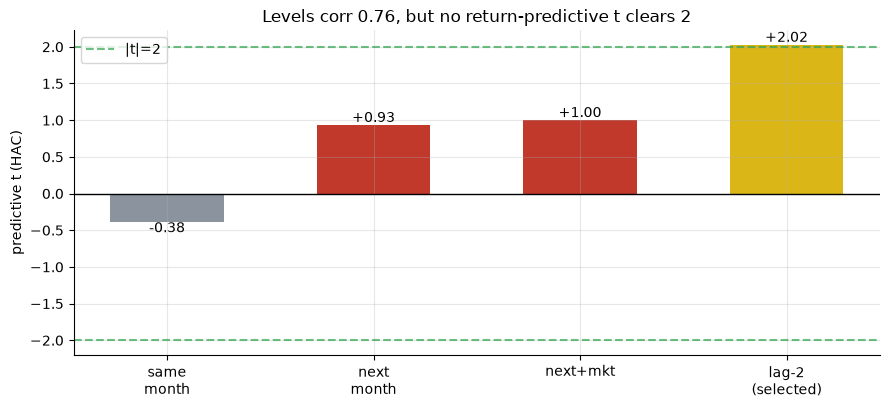

In [2]:
if HAVE:
    lvl_corr = float(np.corrcoef(PANEL['egg'], PANEL['calm'])[0,1])
    cm = st.contemporaneous(PANEL); p1 = st.predictive(PANEL, lag=1)
    p2 = st.predictive(PANEL, lag=2); p1s = st.predictive(PANEL, lag=1, control_spy=True)
    rows = [('egg LEVEL vs CALM LEVEL (corr)', lvl_corr, None),
            ('same-month  r_t ~ g_t', cm['slope'], cm['t']),
            ('next-month  r_{t+1} ~ g_t', p1['slope'], p1['t']),
            ('next-month + market control', p1s['slope'], p1s['t']),
            ('two-month   r_{t+2} ~ g_t (selected lag)', p2['slope'], p2['t'])]
else:
    rows = [('egg LEVEL vs CALM LEVEL (corr)', R['level_corr'], None),
            ('same-month  r_t ~ g_t', None, R['contemp_t']),
            ('next-month  r_{t+1} ~ g_t', R['pred1_slope'], R['pred1_t']),
            ('next-month + market control', None, R['pred1_spy_t']),
            ('two-month   r_{t+2} ~ g_t (selected lag)', R['pred2_slope'], R['pred2_t'])]
print(f"{'relationship':40s} {'slope':>8s} {'t':>7s}")
for name, s, t in rows:
    print(f"{name:40s} {('' if s is None else f'{s:+.3f}'):>8s} {('' if t is None else f'{t:+.2f}'):>7s}")
labs = ['same\nmonth', 'next\nmonth', 'next+mkt', 'lag-2\n(selected)']
tv = [rows[1][2], rows[2][2], rows[3][2], rows[4][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(labs, tv, .55, color=[GREY, RED, RED, AMBER])
ax.axhline(2, ls='--', c=GREEN, alpha=.7, label='|t|=2'); ax.axhline(-2, ls='--', c=GREEN, alpha=.7)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('predictive t (HAC)')
for i,t in enumerate(tv): ax.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_title(f"Levels corr {R['level_corr']:.2f}, but no return-predictive t clears 2"); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: the **0.76** you'd quote at a dinner party is a spurious-regression artifact — two integrated, upward-drifting series. The moment you ask the honest question (does a *change* forecast a *return*?) it collapses: next-month *t* = **0.93**, and adding the contemporaneous market barely moves it (**1.00**). The lag-2 *t* = 2.02 is the one number a data-miner would frame — so we test it next.

### 4b · The placebo — is the lag-2 *t* = 2.02 real, or a mined lag?

Circular-shift the egg series (preserving its autocorrelation), re-fit the predictive regression thousands of times, and locate the observed *t* in the null — for **both** lags.

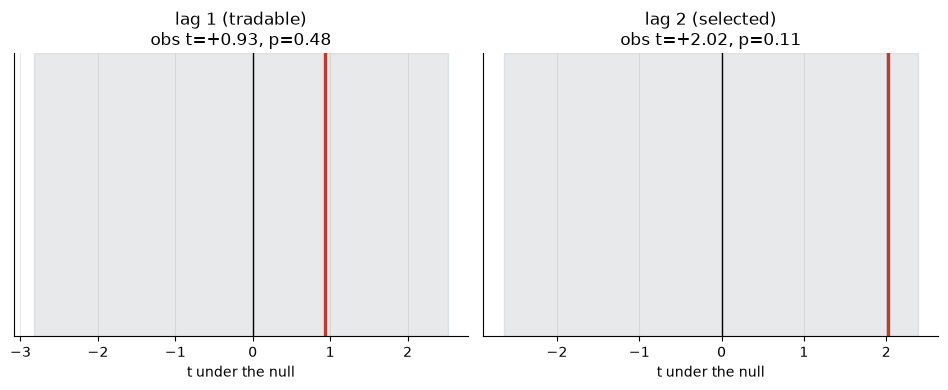

lag1: obs t=+0.93  placebo p=0.483
lag2: obs t=+2.02  placebo p=0.111  <- the 'significant' lag is NOT significant vs its placebo


In [3]:
if HAVE:
    pl1 = st.circular_shift_placebo(PANEL, lag=1, n_boot=5000, seed=725)
    pl2 = st.circular_shift_placebo(PANEL, lag=2, n_boot=5000, seed=725)
else:
    pl1 = dict(obs_t=R['plac1_t'], p=R['plac1_p'], lo=-2.0, hi=2.0)
    pl2 = dict(obs_t=R['plac2_t'], p=R['plac2_p'], lo=-2.1, hi=2.1)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True)
for ax, pl, lab in zip(axes, [pl1, pl2], ['lag 1 (tradable)', 'lag 2 (selected)']):
    ax.axvspan(pl['lo'], pl['hi'], color=GREY, alpha=.2)
    ax.axvline(pl['obs_t'], c=RED, lw=2.4)
    ax.axvline(0, c='k', lw=1); ax.set_yticks([])
    ax.set_title(f"{lab}\nobs t={pl['obs_t']:+.2f}, p={pl['p']:.2f}"); ax.set_xlabel('t under the null')
plt.tight_layout(); plt.show()
print(f"lag1: obs t={pl1['obs_t']:+.2f}  placebo p={pl1['p']:.3f}")
print(f"lag2: obs t={pl2['obs_t']:+.2f}  placebo p={pl2['p']:.3f}  <- the 'significant' lag is NOT significant vs its placebo")

> 💡 In plain words: the tradable lag-1 signal sits squarely inside its noise band (*p* = **0.48**). And the tempting lag-2 *t* = **2.02** — the kind of number that launches a strategy — **fails its own placebo** (*p* = **0.11**): once you account for having *searched* across lags, it's exactly what random time-shifts produce. H₁ and H₂ rejected.

### 4c · The reverse regression — the stock leads the print

The mechanism. Regress the **next** egg-price change on **this** month's CALM return: $g_{t+1} = a + b\,r_t + e$, at lags 1 and 2.

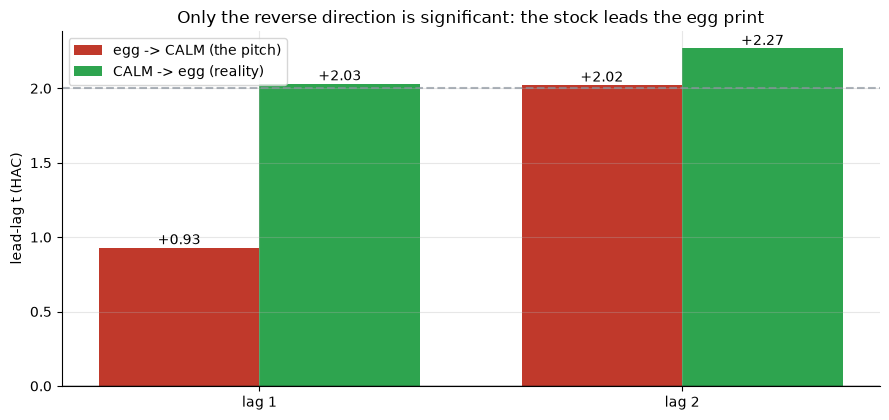

egg->CALM: lag1 t=+0.93, lag2 t=+2.02  (nothing survives placebo)
CALM->egg: lag1 t=+2.03, lag2 t=+2.27  (the real lead-lag)


In [4]:
if HAVE:
    f1 = st.predictive(PANEL, lag=1)['t']; f2 = st.predictive(PANEL, lag=2)['t']
    r1 = st.reverse_lead(PANEL, lag=1)['t']; r2 = st.reverse_lead(PANEL, lag=2)['t']
else:
    f1,f2,r1,r2 = R['pred1_t'], R['pred2_t'], R['rev1_t'], R['rev2_t']
x = np.arange(2); w=.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-w/2, [f1,f2], w, color=RED, label='egg -> CALM (the pitch)')
ax.bar(x+w/2, [r1,r2], w, color=GREEN, label='CALM -> egg (reality)')
ax.axhline(2, ls='--', c=GREY, alpha=.7); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(['lag 1', 'lag 2']); ax.set_ylabel('lead-lag t (HAC)')
for xi,v in zip([x[0]-w/2,x[1]-w/2,x[0]+w/2,x[1]+w/2],[f1,f2,r1,r2]): ax.annotate(f'{v:+.2f}',(xi,v),ha='center',va='bottom')
ax.set_title('Only the reverse direction is significant: the stock leads the egg print'); ax.legend()
plt.tight_layout(); plt.show()
print(f"egg->CALM: lag1 t={f1:+.2f}, lag2 t={f2:+.2f}  (nothing survives placebo)")
print(f"CALM->egg: lag1 t={r1:+.2f}, lag2 t={r2:+.2f}  (the real lead-lag)")

> 💡 In plain words: CALM's return foreshadows the next retail egg print at *t* ≈ **2.0** (and **2.3** at two months), while the egg print → CALM direction is dead. The equity market aggregates wholesale egg futures, USDA flock/HPAI data and company guidance and prices the shortage *weeks before* it reaches the supermarket shelf and the CPI table. The public number is a lagging summary — a receipt, not a signal. **`Already priced in? → CONFIRMED`.**

### 4d · The money test — an egg-momentum timer, net of costs

Long CALM when trailing 3-month egg momentum > 0 (acted on with a one-month lag), cash at 2%/yr otherwise; 10 bp one-way per switch. Raced on **excess-of-cash** Sharpe against buy-and-hold CALM and SPY.

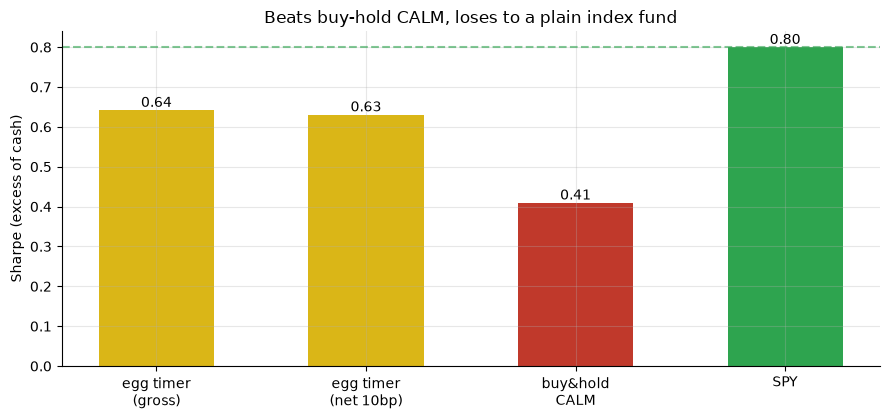

timer gross Sharpe 0.64 (CAGR +13.9%, maxDD -20%)
timer net   Sharpe 0.63 (CAGR +13.7%)  | 25 switches, long 54% of months
buy&hold CALM Sharpe 0.41 (CAGR +10.1%, maxDD -34%)
SPY          Sharpe 0.80 (CAGR +13.7%)


In [5]:
if HAVE:
    tm = st.egg_momentum_timer(PANEL, window=3); net = st.apply_costs(tm, 10.0)
    g = st.summarize(tm['timer']); nn = st.summarize(net)
    cc = st.summarize(tm['calm']); sp = st.summarize(tm['spy'])
    frac = float(tm['signal'].mean()); sw = int((tm['signal'].diff().abs()>0).sum())
else:
    g = dict(sharpe=R['timer_sh'],cagr=R['timer_cagr']/100,mdd=R['timer_mdd']/100)
    nn = dict(sharpe=R['net_sh'],cagr=R['net_cagr']/100,mdd=R['timer_mdd']/100)
    cc = dict(sharpe=R['calm_sh'],cagr=R['calm_cagr']/100,mdd=R['calm_mdd']/100)
    sp = dict(sharpe=R['spy_sh'],cagr=R['spy_cagr']/100,mdd=-0.24)
    frac=R['frac_long']; sw=R['switches']
names=['egg timer\n(gross)','egg timer\n(net 10bp)','buy&hold\nCALM','SPY']
shs=[g['sharpe'], nn['sharpe'], cc['sharpe'], sp['sharpe']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(names, shs, .55, color=[AMBER, AMBER, RED, GREEN])
ax.axhline(sp['sharpe'], ls='--', c=GREEN, alpha=.6)
for i,v in enumerate(shs): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (excess of cash)'); ax.set_title('Beats buy-hold CALM, loses to a plain index fund')
plt.tight_layout(); plt.show()
print(f"timer gross Sharpe {g['sharpe']:.2f} (CAGR {g['cagr']*100:+.1f}%, maxDD {g['mdd']*100:.0f}%)")
print(f"timer net   Sharpe {nn['sharpe']:.2f} (CAGR {nn['cagr']*100:+.1f}%)  | {sw} switches, long {frac*100:.0f}% of months")
print(f"buy&hold CALM Sharpe {cc['sharpe']:.2f} (CAGR {cc['cagr']*100:+.1f}%, maxDD {cc['mdd']*100:.0f}%)")
print(f"SPY          Sharpe {sp['sharpe']:.2f} (CAGR {sp['cagr']*100:+.1f}%)")

> 💡 In plain words: the timer's net Sharpe **0.63** *does* edge buy-and-hold CALM (**0.41**) — but that's **risk reduction from sitting in cash** during CALM's slumps, not forecasting skill (the egg print predicts nothing, §4a–b). Costs barely bite (25 switches). And it still trails a plain **SPY** at **0.80**: you shouldered concentrated single-name, three-event, one-commodity risk to *underperform the index*. `MIRAGE`.

### 4e · Positive control — the engine recovers a planted lead

A deterministic world where $r_{t+1} = 0.6\,g_t + \text{noise}$ (seed 725). The harness must recover *t* ≥ 2, a placebo *p* ≈ 0 and a paying timer — proving the real-tape nulls are true nulls, not a broken pipeline. The β = 0 world must stay flat.

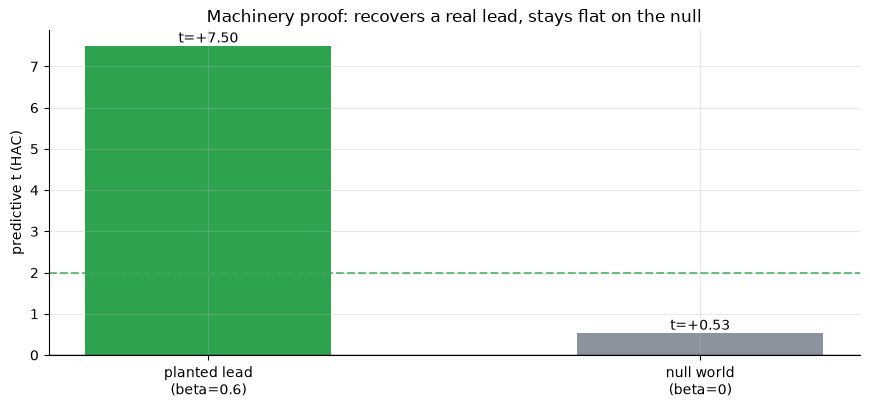

planted lead: slope +0.646  t +7.50  placebo p 0.000  recovered=1
null world:   t +0.53  recovered=0
planted timer Sharpe 0.64 vs buy-hold 0.27


In [6]:
w = data.synthetic_world(lead_beta=0.6); w0 = data.synthetic_world(lead_beta=0.0)
pr = st.predictive(w, lag=1); pl = st.circular_shift_placebo(w, lag=1, n_boot=3000, seed=725)
cr = st.control_recovers(w, lag=1); pr0 = st.predictive(w0, lag=1)
tmw = st.egg_momentum_timer(w)
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(['planted lead\n(beta=0.6)','null world\n(beta=0)'], [pr['t'], pr0['t']],
       .5, color=[GREEN, GREY])
ax.axhline(2, ls='--', c=GREEN, alpha=.7); ax.axhline(0, c='k', lw=1)
for i,t in enumerate([pr['t'], pr0['t']]): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('predictive t (HAC)'); ax.set_title('Machinery proof: recovers a real lead, stays flat on the null')
plt.tight_layout(); plt.show()
print(f"planted lead: slope {pr['slope']:+.3f}  t {pr['t']:+.2f}  placebo p {pl['p']:.3f}  recovered={cr['recovered']}")
print(f"null world:   t {pr0['t']:+.2f}  recovered={st.control_recovers(w0,1)['recovered']}")
print(f"planted timer Sharpe {st.summarize(tmw['timer'])['sharpe']:.2f} vs buy-hold {st.summarize(tmw['calm'])['sharpe']:.2f}")

> 💡 In plain words: when a real lead is present, the engine nails it — *t* = **7.5**, placebo *p* = **0**, timer Sharpe **0.65** vs buy-hold **0.27** — and on the null it reads *t* = **0.53** (flat). So the real-tape `NONE` is a *true* null: the egg print genuinely doesn't lead CALM, not a harness that couldn't see it. A synthetic control is a machinery proof, never market evidence.

## 5 · The verdict

- **Signal `NONE`** — predictive lag-1 egg→CALM *t* = 0.93 (placebo *p* = 0.48); +market control 1.00; the lag-2 *t* = 2.02 fails its placebo (*p* = 0.11). The 0.76 level correlation is a spurious-regression artifact. No robust *t* ≥ 2 in the tradable direction.
- **Tradability `MIRAGE`** — egg-momentum timer net Sharpe 0.63 beats buy-hold CALM (0.41) via cash-parking, not signal, and **loses to SPY** (0.80). Single-name, three-event, one-commodity concentration for sub-index returns.
- **Already priced in? `CONFIRMED`** — the reverse regression is the only significant one: CALM leads the next egg print (*t* = 2.03, lag-2 2.27). The public retail number lags the equity that's supposed to be forecast by it.

## 6 · Could you trade it? — capacity & cost reality

Even granting the timer's edge over buy-hold CALM, the trade has no room to grow: it is one mid-cap name (CALM), it fires on ~three flu episodes in a decade, and it is a bet on a single agricultural commodity. Terminal wealth of \$10,000 makes the point.

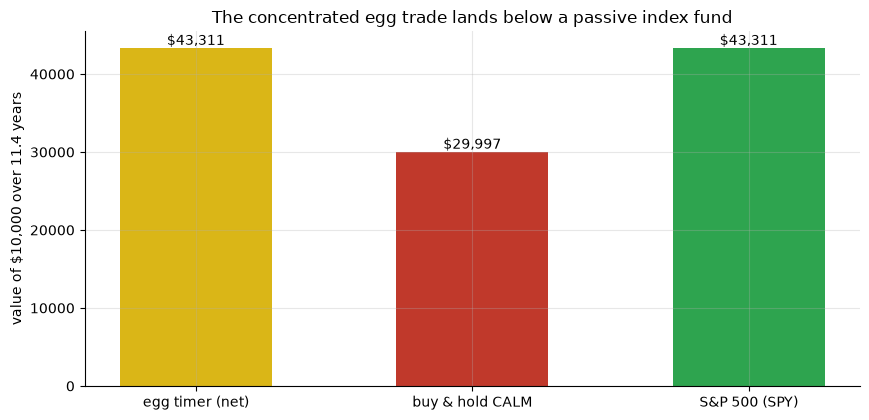

egg timer (net)    $    43,311  (+13.7%/yr)
buy & hold CALM    $    29,997  (+10.1%/yr)
S&P 500 (SPY)      $    43,311  (+13.7%/yr)


In [7]:
start=10_000.0; yrs=R['n']/12
paths={'egg timer (net)':R['net_cagr']/100, 'buy & hold CALM':R['calm_cagr']/100, 'S&P 500 (SPY)':R['spy_cagr']/100}
ends={k:start*(1+g)**yrs for k,g in paths.items()}
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(list(ends), list(ends.values()), .55, color=[AMBER, RED, GREEN])
for i,v in enumerate(ends.values()): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel(f'value of $10,000 over {yrs:.1f} years'); ax.set_title('The concentrated egg trade lands below a passive index fund')
plt.tight_layout(); plt.show()
for k,g in paths.items(): print(f"{k:18s} ${start*(1+g)**yrs:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: the egg timer and SPY end up close in dollars, but SPY got there with **broad diversification and a higher Sharpe**, while the egg book concentrated everything into one stock's exposure to one bird-flu-driven commodity. Same-ish money, far more risk, and a signal (the egg print) that we showed does no work. There is no size or venue that turns a lagging public statistic into an edge.

## 7 · Going further

- **Swap in the live BLS/USDA feed.** Replace the hardcoded egg series with BLS `APU0000708111` (retail) or the USDA wholesale/Egg Markets Overview; re-run — the reverse lead-lag sign is robust to the exact series.
- **Race the leading indicators.** Wholesale egg futures, weekly USDA cull counts, or Google-Trends 'egg price' — test whether *any* of them beat the stock to the punch with a next-period *t* ≥ 2 that survives a placebo.
- **The 'trade the headline' prior.** Public alt-data that co-moves but doesn't *lead* is the family rule, not the exception ([docs/references.md](../docs/references.md)); this is the egg instance of a market that prices news before it prints.

*The reproducible core is offline and deterministic; the egg series is a **cited, approximate proxy** and CALM/SPY are real month-end tape. Methods: [`docs/references.md`](../docs/references.md); frozen numbers (fp `0c92a7548d09`): [`docs/results.md`](../docs/results.md).*